# Estudo de Caso — Sistema de Vendas e Distribuição (Northwind)
###Cenário

A empresa Global Commerce Distribution atua na comercialização e distribuição de produtos para diversos clientes ao redor do mundo.
O sistema utiliza um banco de dados relacional para controlar:

* Clientes
* Funcionários
* Pedidos
* Produtos
* Categorias
* Fornecedores
* Transportadoras
* Regiões e territórios

A diretoria deseja gerar relatórios inteligentes e automatizar cálculos utilizando FUNCTIONS no MySQL.

## Estrutura do Banco de Dados

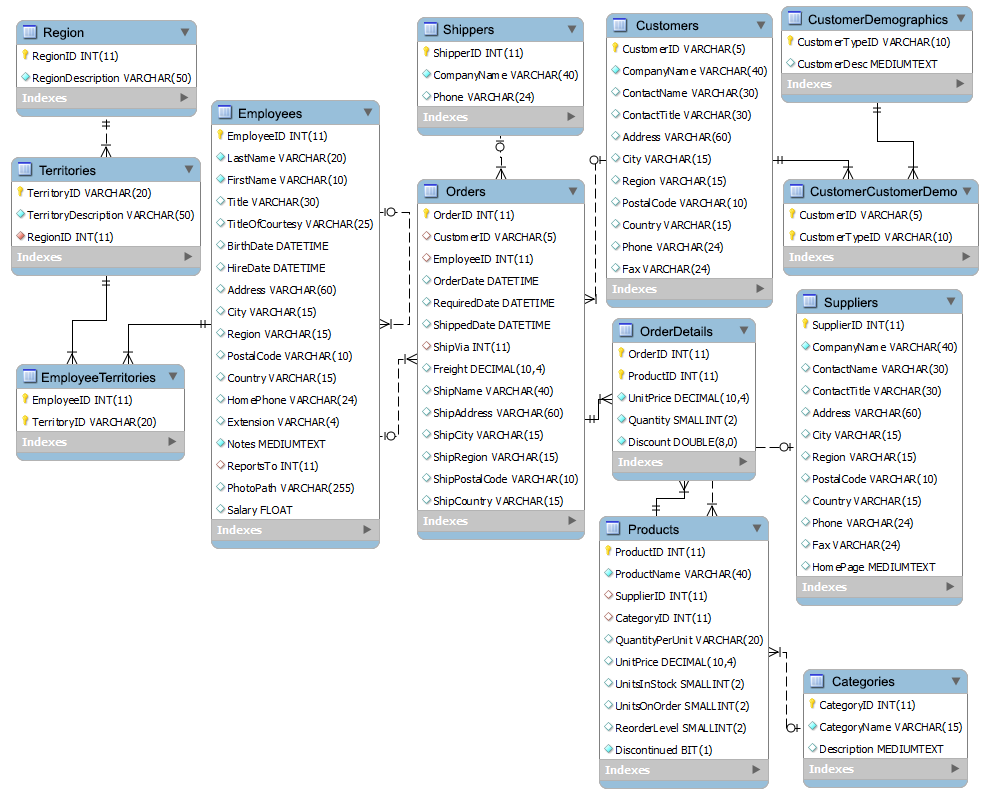

# Objetivos da Atividade


* Interpretar o DER
* Criar consultas SQL
* Desenvolver FUNCTIONS no MySQL
* Aplicar regras de negócio
* Trabalhar com cálculos e manipulação de dados
* Integrar múltiplas tabelas

# Script Banco de Dados

```sql
-- phpMyAdmin SQL Dump
-- version 4.0.10.7
-- http://www.phpmyadmin.net
--
-- Host: localhost
-- Generation Time: Mar 20, 2015 at 01:43 AM
-- Server version: 5.5.34-cll-lve
-- PHP Version: 5.4.23

SET SQL_MODE = "NO_AUTO_VALUE_ON_ZERO";
SET time_zone = "+00:00";


/*!40101 SET @OLD_CHARACTER_SET_CLIENT=@@CHARACTER_SET_CLIENT */;
/*!40101 SET @OLD_CHARACTER_SET_RESULTS=@@CHARACTER_SET_RESULTS */;
/*!40101 SET @OLD_COLLATION_CONNECTION=@@COLLATION_CONNECTION */;
/*!40101 SET NAMES utf8 */;

--
-- Database: `wrpracti_bookinfo`
--

-- --------------------------------------------------------

--
-- Table structure for table `countries`
--

CREATE TABLE IF NOT EXISTS `countries` (
  `COUNTRY_ID` varchar(2) NOT NULL,
  `COUNTRY_NAME` varchar(40) DEFAULT NULL,
  `REGION_ID` decimal(10,0) DEFAULT NULL,
  PRIMARY KEY (`COUNTRY_ID`),
  KEY `COUNTR_REG_FK` (`REGION_ID`)
) ENGINE=MyISAM DEFAULT CHARSET=latin1;

--
-- Dumping data for table `countries`
--

INSERT INTO `countries` (`COUNTRY_ID`, `COUNTRY_NAME`, `REGION_ID`) VALUES
('AR', 'Argentina', '2'),
('AU', 'Australia', '3'),
('BE', 'Belgium', '1'),
('BR', 'Brazil', '2'),
('CA', 'Canada', '2'),
('CH', 'Switzerland', '1'),
('CN', 'China', '3'),
('DE', 'Germany', '1'),
('DK', 'Denmark', '1'),
('EG', 'Egypt', '4'),
('FR', 'France', '1'),
('HK', 'HongKong', '3'),
('IL', 'Israel', '4'),
('IN', 'India', '3'),
('IT', 'Italy', '1'),
('JP', 'Japan', '3'),
('KW', 'Kuwait', '4'),
('MX', 'Mexico', '2'),
('NG', 'Nigeria', '4'),
('NL', 'Netherlands', '1'),
('SG', 'Singapore', '3'),
('UK', 'United Kingdom', '1'),
('US', 'United States of America', '2'),
('ZM', 'Zambia', '4'),
('ZW', 'Zimbabwe', '4');

-- --------------------------------------------------------

--
-- Table structure for table `departments`
--

CREATE TABLE IF NOT EXISTS `departments` (
  `DEPARTMENT_ID` decimal(4,0) NOT NULL DEFAULT '0',
  `DEPARTMENT_NAME` varchar(30) NOT NULL,
  `MANAGER_ID` decimal(6,0) DEFAULT NULL,
  `LOCATION_ID` decimal(4,0) DEFAULT NULL,
  PRIMARY KEY (`DEPARTMENT_ID`),
  KEY `DEPT_MGR_FK` (`MANAGER_ID`),
  KEY `DEPT_LOCATION_IX` (`LOCATION_ID`)
) ENGINE=MyISAM DEFAULT CHARSET=latin1;

--
-- Dumping data for table `departments`
--

INSERT INTO `departments` (`DEPARTMENT_ID`, `DEPARTMENT_NAME`, `MANAGER_ID`, `LOCATION_ID`) VALUES
('10', 'Administration', '200', '1700'),
('20', 'Marketing', '201', '1800'),
('30', 'Purchasing', '114', '1700'),
('40', 'Human Resources', '203', '2400'),
('50', 'Shipping', '121', '1500'),
('60', 'IT', '103', '1400'),
('70', 'Public Relations', '204', '2700'),
('80', 'Sales', '145', '2500'),
('90', 'Executive', '100', '1700'),
('100', 'Finance', '108', '1700'),
('110', 'Accounting', '205', '1700'),
('120', 'Treasury', '0', '1700'),
('130', 'Corporate Tax', '0', '1700'),
('140', 'Control And Credit', '0', '1700'),
('150', 'Shareholder Services', '0', '1700'),
('160', 'Benefits', '0', '1700'),
('170', 'Manufacturing', '0', '1700'),
('180', 'Construction', '0', '1700'),
('190', 'Contracting', '0', '1700'),
('200', 'Operations', '0', '1700'),
('210', 'IT Support', '0', '1700'),
('220', 'NOC', '0', '1700'),
('230', 'IT Helpdesk', '0', '1700'),
('240', 'Government Sales', '0', '1700'),
('250', 'Retail Sales', '0', '1700'),
('260', 'Recruiting', '0', '1700'),
('270', 'Payroll', '0', '1700');

-- --------------------------------------------------------

--
-- Table structure for table `employees`
--

CREATE TABLE IF NOT EXISTS `employees` (
  `EMPLOYEE_ID` decimal(6,0) NOT NULL DEFAULT '0',
  `FIRST_NAME` varchar(20) DEFAULT NULL,
  `LAST_NAME` varchar(25) NOT NULL,
  `EMAIL` varchar(25) NOT NULL,
  `PHONE_NUMBER` varchar(20) DEFAULT NULL,
  `HIRE_DATE` date NOT NULL,
  `JOB_ID` varchar(10) NOT NULL,
  `SALARY` decimal(8,2) DEFAULT NULL,
  `COMMISSION_PCT` decimal(2,2) DEFAULT NULL,
  `MANAGER_ID` decimal(6,0) DEFAULT NULL,
  `DEPARTMENT_ID` decimal(4,0) DEFAULT NULL,
  PRIMARY KEY (`EMPLOYEE_ID`),
  UNIQUE KEY `EMP_EMAIL_UK` (`EMAIL`),
  KEY `EMP_DEPARTMENT_IX` (`DEPARTMENT_ID`),
  KEY `EMP_JOB_IX` (`JOB_ID`),
  KEY `EMP_MANAGER_IX` (`MANAGER_ID`),
  KEY `EMP_NAME_IX` (`LAST_NAME`,`FIRST_NAME`)
) ENGINE=MyISAM DEFAULT CHARSET=latin1;

--
-- Dumping data for table `employees`
--

INSERT INTO `employees` (`EMPLOYEE_ID`, `FIRST_NAME`, `LAST_NAME`, `EMAIL`, `PHONE_NUMBER`, `HIRE_DATE`, `JOB_ID`, `SALARY`, `COMMISSION_PCT`, `MANAGER_ID`, `DEPARTMENT_ID`) VALUES
('100', 'Steven', 'King', 'SKING', '515.123.4567', '1987-06-17', 'AD_PRES', '24000.00', '0.00', '0', '90'),
('101', 'Neena', 'Kochhar', 'NKOCHHAR', '515.123.4568', '1987-06-18', 'AD_VP', '17000.00', '0.00', '100', '90'),
('102', 'Lex', 'De Haan', 'LDEHAAN', '515.123.4569', '1987-06-19', 'AD_VP', '17000.00', '0.00', '100', '90'),
('103', 'Alexander', 'Hunold', 'AHUNOLD', '590.423.4567', '1987-06-20', 'IT_PROG', '9000.00', '0.00', '102', '60'),
('104', 'Bruce', 'Ernst', 'BERNST', '590.423.4568', '1987-06-21', 'IT_PROG', '6000.00', '0.00', '103', '60'),
('105', 'David', 'Austin', 'DAUSTIN', '590.423.4569', '1987-06-22', 'IT_PROG', '4800.00', '0.00', '103', '60'),
('106', 'Valli', 'Pataballa', 'VPATABAL', '590.423.4560', '1987-06-23', 'IT_PROG', '4800.00', '0.00', '103', '60'),
('107', 'Diana', 'Lorentz', 'DLORENTZ', '590.423.5567', '1987-06-24', 'IT_PROG', '4200.00', '0.00', '103', '60'),
('108', 'Nancy', 'Greenberg', 'NGREENBE', '515.124.4569', '1987-06-25', 'FI_MGR', '12000.00', '0.00', '101', '100'),
('109', 'Daniel', 'Faviet', 'DFAVIET', '515.124.4169', '1987-06-26', 'FI_ACCOUNT', '9000.00', '0.00', '108', '100'),
('110', 'John', 'Chen', 'JCHEN', '515.124.4269', '1987-06-27', 'FI_ACCOUNT', '8200.00', '0.00', '108', '100'),
('111', 'Ismael', 'Sciarra', 'ISCIARRA', '515.124.4369', '1987-06-28', 'FI_ACCOUNT', '7700.00', '0.00', '108', '100'),
('112', 'Jose Manuel', 'Urman', 'JMURMAN', '515.124.4469', '1987-06-29', 'FI_ACCOUNT', '7800.00', '0.00', '108', '100'),
('113', 'Luis', 'Popp', 'LPOPP', '515.124.4567', '1987-06-30', 'FI_ACCOUNT', '6900.00', '0.00', '108', '100'),
('114', 'Den', 'Raphaely', 'DRAPHEAL', '515.127.4561', '1987-07-01', 'PU_MAN', '11000.00', '0.00', '100', '30'),
('115', 'Alexander', 'Khoo', 'AKHOO', '515.127.4562', '1987-07-02', 'PU_CLERK', '3100.00', '0.00', '114', '30'),
('116', 'Shelli', 'Baida', 'SBAIDA', '515.127.4563', '1987-07-03', 'PU_CLERK', '2900.00', '0.00', '114', '30'),
('117', 'Sigal', 'Tobias', 'STOBIAS', '515.127.4564', '1987-07-04', 'PU_CLERK', '2800.00', '0.00', '114', '30'),
('118', 'Guy', 'Himuro', 'GHIMURO', '515.127.4565', '1987-07-05', 'PU_CLERK', '2600.00', '0.00', '114', '30'),
('119', 'Karen', 'Colmenares', 'KCOLMENA', '515.127.4566', '1987-07-06', 'PU_CLERK', '2500.00', '0.00', '114', '30'),
('120', 'Matthew', 'Weiss', 'MWEISS', '650.123.1234', '1987-07-07', 'ST_MAN', '8000.00', '0.00', '100', '50'),
('121', 'Adam', 'Fripp', 'AFRIPP', '650.123.2234', '1987-07-08', 'ST_MAN', '8200.00', '0.00', '100', '50'),
('122', 'Payam', 'Kaufling', 'PKAUFLIN', '650.123.3234', '1987-07-09', 'ST_MAN', '7900.00', '0.00', '100', '50'),
('123', 'Shanta', 'Vollman', 'SVOLLMAN', '650.123.4234', '1987-07-10', 'ST_MAN', '6500.00', '0.00', '100', '50'),
('124', 'Kevin', 'Mourgos', 'KMOURGOS', '650.123.5234', '1987-07-11', 'ST_MAN', '5800.00', '0.00', '100', '50'),
('125', 'Julia', 'Nayer', 'JNAYER', '650.124.1214', '1987-07-12', 'ST_CLERK', '3200.00', '0.00', '120', '50'),
('126', 'Irene', 'Mikkilineni', 'IMIKKILI', '650.124.1224', '1987-07-13', 'ST_CLERK', '2700.00', '0.00', '120', '50'),
('127', 'James', 'Landry', 'JLANDRY', '650.124.1334', '1987-07-14', 'ST_CLERK', '2400.00', '0.00', '120', '50'),
('128', 'Steven', 'Markle', 'SMARKLE', '650.124.1434', '1987-07-15', 'ST_CLERK', '2200.00', '0.00', '120', '50'),
('129', 'Laura', 'Bissot', 'LBISSOT', '650.124.5234', '1987-07-16', 'ST_CLERK', '3300.00', '0.00', '121', '50'),
('130', 'Mozhe', 'Atkinson', 'MATKINSO', '650.124.6234', '1987-07-17', 'ST_CLERK', '2800.00', '0.00', '121', '50'),
('131', 'James', 'Marlow', 'JAMRLOW', '650.124.7234', '1987-07-18', 'ST_CLERK', '2500.00', '0.00', '121', '50'),
('132', 'TJ', 'Olson', 'TJOLSON', '650.124.8234', '1987-07-19', 'ST_CLERK', '2100.00', '0.00', '121', '50'),
('133', 'Jason', 'Mallin', 'JMALLIN', '650.127.1934', '1987-07-20', 'ST_CLERK', '3300.00', '0.00', '122', '50'),
('134', 'Michael', 'Rogers', 'MROGERS', '650.127.1834', '1987-07-21', 'ST_CLERK', '2900.00', '0.00', '122', '50'),
('135', 'Ki', 'Gee', 'KGEE', '650.127.1734', '1987-07-22', 'ST_CLERK', '2400.00', '0.00', '122', '50'),
('136', 'Hazel', 'Philtanker', 'HPHILTAN', '650.127.1634', '1987-07-23', 'ST_CLERK', '2200.00', '0.00', '122', '50'),
('137', 'Renske', 'Ladwig', 'RLADWIG', '650.121.1234', '1987-07-24', 'ST_CLERK', '3600.00', '0.00', '123', '50'),
('138', 'Stephen', 'Stiles', 'SSTILES', '650.121.2034', '1987-07-25', 'ST_CLERK', '3200.00', '0.00', '123', '50'),
('139', 'John', 'Seo', 'JSEO', '650.121.2019', '1987-07-26', 'ST_CLERK', '2700.00', '0.00', '123', '50'),
('140', 'Joshua', 'Patel', 'JPATEL', '650.121.1834', '1987-07-27', 'ST_CLERK', '2500.00', '0.00', '123', '50'),
('141', 'Trenna', 'Rajs', 'TRAJS', '650.121.8009', '1987-07-28', 'ST_CLERK', '3500.00', '0.00', '124', '50'),
('142', 'Curtis', 'Davies', 'CDAVIES', '650.121.2994', '1987-07-29', 'ST_CLERK', '3100.00', '0.00', '124', '50'),
('143', 'Randall', 'Matos', 'RMATOS', '650.121.2874', '1987-07-30', 'ST_CLERK', '2600.00', '0.00', '124', '50'),
('144', 'Peter', 'Vargas', 'PVARGAS', '650.121.2004', '1987-07-31', 'ST_CLERK', '2500.00', '0.00', '124', '50'),
('145', 'John', 'Russell', 'JRUSSEL', '011.44.1344.429268', '1987-08-01', 'SA_MAN', '14000.00', '0.40', '100', '80'),
('146', 'Karen', 'Partners', 'KPARTNER', '011.44.1344.467268', '1987-08-02', 'SA_MAN', '13500.00', '0.30', '100', '80'),
('147', 'Alberto', 'Errazuriz', 'AERRAZUR', '011.44.1344.429278', '1987-08-03', 'SA_MAN', '12000.00', '0.30', '100', '80'),
('148', 'Gerald', 'Cambrault', 'GCAMBRAU', '011.44.1344.619268', '1987-08-04', 'SA_MAN', '11000.00', '0.30', '100', '80'),
('149', 'Eleni', 'Zlotkey', 'EZLOTKEY', '011.44.1344.429018', '1987-08-05', 'SA_MAN', '10500.00', '0.20', '100', '80'),
('150', 'Peter', 'Tucker', 'PTUCKER', '011.44.1344.129268', '1987-08-06', 'SA_REP', '10000.00', '0.30', '145', '80'),
('151', 'David', 'Bernstein', 'DBERNSTE', '011.44.1344.345268', '1987-08-07', 'SA_REP', '9500.00', '0.25', '145', '80'),
('152', 'Peter', 'Hall', 'PHALL', '011.44.1344.478968', '1987-08-08', 'SA_REP', '9000.00', '0.25', '145', '80'),
('153', 'Christopher', 'Olsen', 'COLSEN', '011.44.1344.498718', '1987-08-09', 'SA_REP', '8000.00', '0.20', '145', '80'),
('154', 'Nanette', 'Cambrault', 'NCAMBRAU', '011.44.1344.987668', '1987-08-10', 'SA_REP', '7500.00', '0.20', '145', '80'),
('155', 'Oliver', 'Tuvault', 'OTUVAULT', '011.44.1344.486508', '1987-08-11', 'SA_REP', '7000.00', '0.15', '145', '80'),
('156', 'Janette', 'King', 'JKING', '011.44.1345.429268', '1987-08-12', 'SA_REP', '10000.00', '0.35', '146', '80'),
('157', 'Patrick', 'Sully', 'PSULLY', '011.44.1345.929268', '1987-08-13', 'SA_REP', '9500.00', '0.35', '146', '80'),
('158', 'Allan', 'McEwen', 'AMCEWEN', '011.44.1345.829268', '1987-08-14', 'SA_REP', '9000.00', '0.35', '146', '80'),
('159', 'Lindsey', 'Smith', 'LSMITH', '011.44.1345.729268', '1987-08-15', 'SA_REP', '8000.00', '0.30', '146', '80'),
('160', 'Louise', 'Doran', 'LDORAN', '011.44.1345.629268', '1987-08-16', 'SA_REP', '7500.00', '0.30', '146', '80'),
('161', 'Sarath', 'Sewall', 'SSEWALL', '011.44.1345.529268', '1987-08-17', 'SA_REP', '7000.00', '0.25', '146', '80'),
('162', 'Clara', 'Vishney', 'CVISHNEY', '011.44.1346.129268', '1987-08-18', 'SA_REP', '10500.00', '0.25', '147', '80'),
('163', 'Danielle', 'Greene', 'DGREENE', '011.44.1346.229268', '1987-08-19', 'SA_REP', '9500.00', '0.15', '147', '80'),
('164', 'Mattea', 'Marvins', 'MMARVINS', '011.44.1346.329268', '1987-08-20', 'SA_REP', '7200.00', '0.10', '147', '80'),
('165', 'David', 'Lee', 'DLEE', '011.44.1346.529268', '1987-08-21', 'SA_REP', '6800.00', '0.10', '147', '80'),
('166', 'Sundar', 'Ande', 'SANDE', '011.44.1346.629268', '1987-08-22', 'SA_REP', '6400.00', '0.10', '147', '80'),
('167', 'Amit', 'Banda', 'ABANDA', '011.44.1346.729268', '1987-08-23', 'SA_REP', '6200.00', '0.10', '147', '80'),
('168', 'Lisa', 'Ozer', 'LOZER', '011.44.1343.929268', '1987-08-24', 'SA_REP', '11500.00', '0.25', '148', '80'),
('169', 'Harrison', 'Bloom', 'HBLOOM', '011.44.1343.829268', '1987-08-25', 'SA_REP', '10000.00', '0.20', '148', '80'),
('170', 'Tayler', 'Fox', 'TFOX', '011.44.1343.729268', '1987-08-26', 'SA_REP', '9600.00', '0.20', '148', '80'),
('171', 'William', 'Smith', 'WSMITH', '011.44.1343.629268', '1987-08-27', 'SA_REP', '7400.00', '0.15', '148', '80'),
('172', 'Elizabeth', 'Bates', 'EBATES', '011.44.1343.529268', '1987-08-28', 'SA_REP', '7300.00', '0.15', '148', '80'),
('173', 'Sundita', 'Kumar', 'SKUMAR', '011.44.1343.329268', '1987-08-29', 'SA_REP', '6100.00', '0.10', '148', '80'),
('174', 'Ellen', 'Abel', 'EABEL', '011.44.1644.429267', '1987-08-30', 'SA_REP', '11000.00', '0.30', '149', '80'),
('175', 'Alyssa', 'Hutton', 'AHUTTON', '011.44.1644.429266', '1987-08-31', 'SA_REP', '8800.00', '0.25', '149', '80'),
('176', 'Jonathon', 'Taylor', 'JTAYLOR', '011.44.1644.429265', '1987-09-01', 'SA_REP', '8600.00', '0.20', '149', '80'),
('177', 'Jack', 'Livingston', 'JLIVINGS', '011.44.1644.429264', '1987-09-02', 'SA_REP', '8400.00', '0.20', '149', '80'),
('178', 'Kimberely', 'Grant', 'KGRANT', '011.44.1644.429263', '1987-09-03', 'SA_REP', '7000.00', '0.15', '149', '0'),
('179', 'Charles', 'Johnson', 'CJOHNSON', '011.44.1644.429262', '1987-09-04', 'SA_REP', '6200.00', '0.10', '149', '80'),
('180', 'Winston', 'Taylor', 'WTAYLOR', '650.507.9876', '1987-09-05', 'SH_CLERK', '3200.00', '0.00', '120', '50'),
('181', 'Jean', 'Fleaur', 'JFLEAUR', '650.507.9877', '1987-09-06', 'SH_CLERK', '3100.00', '0.00', '120', '50'),
('182', 'Martha', 'Sullivan', 'MSULLIVA', '650.507.9878', '1987-09-07', 'SH_CLERK', '2500.00', '0.00', '120', '50'),
('183', 'Girard', 'Geoni', 'GGEONI', '650.507.9879', '1987-09-08', 'SH_CLERK', '2800.00', '0.00', '120', '50'),
('184', 'Nandita', 'Sarchand', 'NSARCHAN', '650.509.1876', '1987-09-09', 'SH_CLERK', '4200.00', '0.00', '121', '50'),
('185', 'Alexis', 'Bull', 'ABULL', '650.509.2876', '1987-09-10', 'SH_CLERK', '4100.00', '0.00', '121', '50'),
('186', 'Julia', 'Dellinger', 'JDELLING', '650.509.3876', '1987-09-11', 'SH_CLERK', '3400.00', '0.00', '121', '50'),
('187', 'Anthony', 'Cabrio', 'ACABRIO', '650.509.4876', '1987-09-12', 'SH_CLERK', '3000.00', '0.00', '121', '50'),
('188', 'Kelly', 'Chung', 'KCHUNG', '650.505.1876', '1987-09-13', 'SH_CLERK', '3800.00', '0.00', '122', '50'),
('189', 'Jennifer', 'Dilly', 'JDILLY', '650.505.2876', '1987-09-14', 'SH_CLERK', '3600.00', '0.00', '122', '50'),
('190', 'Timothy', 'Gates', 'TGATES', '650.505.3876', '1987-09-15', 'SH_CLERK', '2900.00', '0.00', '122', '50'),
('191', 'Randall', 'Perkins', 'RPERKINS', '650.505.4876', '1987-09-16', 'SH_CLERK', '2500.00', '0.00', '122', '50'),
('192', 'Sarah', 'Bell', 'SBELL', '650.501.1876', '1987-09-17', 'SH_CLERK', '4000.00', '0.00', '123', '50'),
('193', 'Britney', 'Everett', 'BEVERETT', '650.501.2876', '1987-09-18', 'SH_CLERK', '3900.00', '0.00', '123', '50'),
('194', 'Samuel', 'McCain', 'SMCCAIN', '650.501.3876', '1987-09-19', 'SH_CLERK', '3200.00', '0.00', '123', '50'),
('195', 'Vance', 'Jones', 'VJONES', '650.501.4876', '1987-09-20', 'SH_CLERK', '2800.00', '0.00', '123', '50'),
('196', 'Alana', 'Walsh', 'AWALSH', '650.507.9811', '1987-09-21', 'SH_CLERK', '3100.00', '0.00', '124', '50'),
('197', 'Kevin', 'Feeney', 'KFEENEY', '650.507.9822', '1987-09-22', 'SH_CLERK', '3000.00', '0.00', '124', '50'),
('198', 'Donald', 'OConnell', 'DOCONNEL', '650.507.9833', '1987-09-23', 'SH_CLERK', '2600.00', '0.00', '124', '50'),
('199', 'Douglas', 'Grant', 'DGRANT', '650.507.9844', '1987-09-24', 'SH_CLERK', '2600.00', '0.00', '124', '50'),
('200', 'Jennifer', 'Whalen', 'JWHALEN', '515.123.4444', '1987-09-25', 'AD_ASST', '4400.00', '0.00', '101', '10'),
('201', 'Michael', 'Hartstein', 'MHARTSTE', '515.123.5555', '1987-09-26', 'MK_MAN', '13000.00', '0.00', '100', '20'),
('202', 'Pat', 'Fay', 'PFAY', '603.123.6666', '1987-09-27', 'MK_REP', '6000.00', '0.00', '201', '20'),
('203', 'Susan', 'Mavris', 'SMAVRIS', '515.123.7777', '1987-09-28', 'HR_REP', '6500.00', '0.00', '101', '40'),
('204', 'Hermann', 'Baer', 'HBAER', '515.123.8888', '1987-09-29', 'PR_REP', '10000.00', '0.00', '101', '70'),
('205', 'Shelley', 'Higgins', 'SHIGGINS', '515.123.8080', '1987-09-30', 'AC_MGR', '12000.00', '0.00', '101', '110'),
('206', 'William', 'Gietz', 'WGIETZ', '515.123.8181', '1987-10-01', 'AC_ACCOUNT', '8300.00', '0.00', '205', '110');

-- --------------------------------------------------------

--
-- Table structure for table `job_history`
--

CREATE TABLE IF NOT EXISTS `job_history` (
  `EMPLOYEE_ID` decimal(6,0) NOT NULL,
  `START_DATE` date NOT NULL,
  `END_DATE` date NOT NULL,
  `JOB_ID` varchar(10) NOT NULL,
  `DEPARTMENT_ID` decimal(4,0) DEFAULT NULL,
  PRIMARY KEY (`EMPLOYEE_ID`,`START_DATE`),
  KEY `JHIST_DEPARTMENT_IX` (`DEPARTMENT_ID`),
  KEY `JHIST_EMPLOYEE_IX` (`EMPLOYEE_ID`),
  KEY `JHIST_JOB_IX` (`JOB_ID`)
) ENGINE=MyISAM DEFAULT CHARSET=latin1;

--
-- Dumping data for table `job_history`
--

INSERT INTO `job_history` (`EMPLOYEE_ID`, `START_DATE`, `END_DATE`, `JOB_ID`, `DEPARTMENT_ID`) VALUES
('102', '1993-01-13', '1998-07-24', 'IT_PROG', '60'),
('101', '1989-09-21', '1993-10-27', 'AC_ACCOUNT', '110'),
('101', '1993-10-28', '1997-03-15', 'AC_MGR', '110'),
('201', '1996-02-17', '1999-12-19', 'MK_REP', '20'),
('114', '1998-03-24', '1999-12-31', 'ST_CLERK', '50'),
('122', '1999-01-01', '1999-12-31', 'ST_CLERK', '50'),
('200', '1987-09-17', '1993-06-17', 'AD_ASST', '90'),
('176', '1998-03-24', '1998-12-31', 'SA_REP', '80'),
('176', '1999-01-01', '1999-12-31', 'SA_MAN', '80'),
('200', '1994-07-01', '1998-12-31', 'AC_ACCOUNT', '90'),
('0', '0000-00-00', '0000-00-00', '', '0');

-- --------------------------------------------------------

--
-- Table structure for table `jobs`
--

CREATE TABLE IF NOT EXISTS `jobs` (
  `JOB_ID` varchar(10) NOT NULL DEFAULT '',
  `JOB_TITLE` varchar(35) NOT NULL,
  `MIN_SALARY` decimal(6,0) DEFAULT NULL,
  `MAX_SALARY` decimal(6,0) DEFAULT NULL,
  PRIMARY KEY (`JOB_ID`)
) ENGINE=MyISAM DEFAULT CHARSET=latin1;

--
-- Dumping data for table `jobs`
--

INSERT INTO `jobs` (`JOB_ID`, `JOB_TITLE`, `MIN_SALARY`, `MAX_SALARY`) VALUES
('AD_PRES', 'President', '20000', '40000'),
('AD_VP', 'Administration Vice President', '15000', '30000'),
('AD_ASST', 'Administration Assistant', '3000', '6000'),
('FI_MGR', 'Finance Manager', '8200', '16000'),
('FI_ACCOUNT', 'Accountant', '4200', '9000'),
('AC_MGR', 'Accounting Manager', '8200', '16000'),
('AC_ACCOUNT', 'Public Accountant', '4200', '9000'),
('SA_MAN', 'Sales Manager', '10000', '20000'),
('SA_REP', 'Sales Representative', '6000', '12000'),
('PU_MAN', 'Purchasing Manager', '8000', '15000'),
('PU_CLERK', 'Purchasing Clerk', '2500', '5500'),
('ST_MAN', 'Stock Manager', '5500', '8500'),
('ST_CLERK', 'Stock Clerk', '2000', '5000'),
('SH_CLERK', 'Shipping Clerk', '2500', '5500'),
('IT_PROG', 'Programmer', '4000', '10000'),
('MK_MAN', 'Marketing Manager', '9000', '15000'),
('MK_REP', 'Marketing Representative', '4000', '9000'),
('HR_REP', 'Human Resources Representative', '4000', '9000'),
('PR_REP', 'Public Relations Representative', '4500', '10500');

-- --------------------------------------------------------

--
-- Table structure for table `locations`
--

CREATE TABLE IF NOT EXISTS `locations` (
  `LOCATION_ID` decimal(4,0) NOT NULL DEFAULT '0',
  `STREET_ADDRESS` varchar(40) DEFAULT NULL,
  `POSTAL_CODE` varchar(12) DEFAULT NULL,
  `CITY` varchar(30) NOT NULL,
  `STATE_PROVINCE` varchar(25) DEFAULT NULL,
  `COUNTRY_ID` varchar(2) DEFAULT NULL,
  PRIMARY KEY (`LOCATION_ID`),
  KEY `LOC_CITY_IX` (`CITY`),
  KEY `LOC_COUNTRY_IX` (`COUNTRY_ID`),
  KEY `LOC_STATE_PROVINCE_IX` (`STATE_PROVINCE`)
) ENGINE=MyISAM DEFAULT CHARSET=latin1;

--
-- Dumping data for table `locations`
--

INSERT INTO `locations` (`LOCATION_ID`, `STREET_ADDRESS`, `POSTAL_CODE`, `CITY`, `STATE_PROVINCE`, `COUNTRY_ID`) VALUES
('1000', '1297 Via Cola di Rie', '989', 'Roma', '', 'IT'),
('1100', '93091 Calle della Testa', '10934', 'Venice', '', 'IT'),
('1200', '2017 Shinjuku-ku', '1689', 'Tokyo', 'Tokyo Prefecture', 'JP'),
('1300', '9450 Kamiya-cho', '6823', 'Hiroshima', '', 'JP'),
('1400', '2014 Jabberwocky Rd', '26192', 'Southlake', 'Texas', 'US'),
('1500', '2011 Interiors Blvd', '99236', 'South San Francisco', 'California', 'US'),
('1600', '2007 Zagora St', '50090', 'South Brunswick', 'New Jersey', 'US'),
('1700', '2004 Charade Rd', '98199', 'Seattle', 'Washington', 'US'),
('1800', '147 Spadina Ave', 'M5V 2L7', 'Toronto', 'Ontario', 'CA'),
('1900', '6092 Boxwood St', 'YSW 9T2', 'Whitehorse', 'Yukon', 'CA'),
('2000', '40-5-12 Laogianggen', '190518', 'Beijing', '', 'CN'),
('2100', '1298 Vileparle (E)', '490231', 'Bombay', 'Maharashtra', 'IN'),
('2200', '12-98 Victoria Street', '2901', 'Sydney', 'New South Wales', 'AU'),
('2300', '198 Clementi North', '540198', 'Singapore', '', 'SG'),
('2400', '8204 Arthur St', '', 'London', '', 'UK'),
('2500', '"Magdalen Centre', ' The Oxford ', 'OX9 9ZB', 'Oxford', 'Ox'),
('2600', '9702 Chester Road', '9629850293', 'Stretford', 'Manchester', 'UK'),
('2700', 'Schwanthalerstr. 7031', '80925', 'Munich', 'Bavaria', 'DE'),
('2800', 'Rua Frei Caneca 1360', '01307-002', 'Sao Paulo', 'Sao Paulo', 'BR'),
('2900', '20 Rue des Corps-Saints', '1730', 'Geneva', 'Geneve', 'CH'),
('3000', 'Murtenstrasse 921', '3095', 'Bern', 'BE', 'CH'),
('3100', 'Pieter Breughelstraat 837', '3029SK', 'Utrecht', 'Utrecht', 'NL'),
('3200', 'Mariano Escobedo 9991', '11932', 'Mexico City', '"Distrito Federal', '"');

-- --------------------------------------------------------

--
-- Table structure for table `regions`
--

CREATE TABLE IF NOT EXISTS `regions` (
  `REGION_ID` decimal(5,0) NOT NULL,
  `REGION_NAME` varchar(25) DEFAULT NULL,
  PRIMARY KEY (`REGION_ID`),
  UNIQUE KEY `sss` (`REGION_NAME`)
) ENGINE=MyISAM DEFAULT CHARSET=latin1;

--
-- Dumping data for table `regions`
--

INSERT INTO `regions` (`REGION_ID`, `REGION_NAME`) VALUES
('1', 'Europe\r'),
('2', 'Americas\r'),
('3', 'Asia\r'),
('4', 'Middle East and Africa\r');

/*!40101 SET CHARACTER_SET_CLIENT=@OLD_CHARACTER_SET_CLIENT */;
/*!40101 SET CHARACTER_SET_RESULTS=@OLD_CHARACTER_SET_RESULTS */;
/*!40101 SET COLLATION_CONNECTION=@OLD_COLLATION_CONNECTION */;
```

# Entendendo o Banco de Dados

| Tabela       | Função            |
| ------------ | ----------------- |
| Customers    | Clientes          |
| Orders       | Pedidos           |
| OrderDetails | Itens dos pedidos |
| Products     | Produtos          |
| Categories   | Categorias        |
| Suppliers    | Fornecedores      |
| Employees    | Funcionários      |
| Shippers     | Transportadoras   |

# Situação-Problema

A empresa deseja automatizar algumas regras do sistema utilizando FUNCTIONS no MySQL.

Você foi contratado como desenvolvedor de banco de dados para implementar essas funcionalidades.

## Atividade 1 — Function para calcular valor total do pedido
Requisito:

Criar uma FUNCTION chamada: `fn_total_pedido()`

Ela deverá:

* Receber o ID do pedido
* Somar:
  * preço do produto
  * quantidade
  * desconto
  * Retornar o valor total do pedido

## Atividade 2 — Function para verificar estoque
Requisito

Criar uma FUNCTION: `fn_verificar_estoque()`

A função deverá:

* Receber o ProductID

Verificar:

* se o produto possui mais de 10 unidades

Retornar:

* "ESTOQUE OK"
* "ESTOQUE BAIXO"

## Atividade 3 — Function para Categoria do Produto

Requisito:

Criar uma FUNCTION:

```sql
fn_categoria_produto()
```

A função deverá:

- Receber o `ProductID`
- Retornar o nome da categoria do produto


## 🔗 Relações necessárias

```text
Products -> Categories
```


## Atividade 4 — Function para Calcular Frete Grátis

Requisito:

Criar uma FUNCTION:

```sql
fn_frete_gratis()
```



###  Regras de Negócio

| Valor do Pedido | Resultado |
|---|---|
| >= 500 | FRETE GRÁTIS |
| < 500 | FRETE COBRADO |

###  Entrada

A função deverá receber:

```text
OrderID
```

###  ⚠️ Importante

A função deve utilizar a FUNCTION criada anteriormente:

```sql
fn_total_pedido()
```

## Atividade 5 — Function para Nível do Cliente

Requisito:

Criar uma FUNCTION:

```sql
fn_nivel_cliente()
```

### Critérios

| Total de Compras | Nível |
|---|---|
| > 10000 | PREMIUM |
| > 5000 | GOLD |
| > 1000 | SILVER |
| restante | BRONZE |


###  Entrada

A função deverá receber:

```text
CustomerID
```



### A função deve

- Somar todos os pedidos do cliente
- Retornar o nível do cliente

###  Tabelas envolvidas

```text
Customers
Orders
OrderDetails
```

## Atividade 6 — Function para Tempo de Entrega

### Requisito

Criar uma FUNCTION:

```sql
fn_tempo_entrega()
```

###  A função deverá

- Receber `OrderID`
- Calcular diferença entre:
  - `OrderDate`
  - `ShippedDate`
- Retornar quantidade de dias

---

###  Função MySQL recomendada

```sql
DATEDIFF()
```


### Tabela utilizada

```text
Orders
```


## Atividade 7 — Dashboard SQL

### Requisito

Crie uma consulta final utilizando as FUNCTIONS criadas anteriormente.



### Objetivo

Construir um mini dashboard SQL contendo:

- Pedido
- Cliente
- Valor total
- Frete
- Tempo de entrega
- Nível do cliente

### Exemplo esperado

```sql
SELECT
    o.OrderID,
    c.CompanyName,
    fn_total_pedido(o.OrderID) AS TotalPedido,
    fn_frete_gratis(o.OrderID) AS Frete,
    fn_tempo_entrega(o.OrderID) AS DiasEntrega,
    fn_nivel_cliente(c.CustomerID) AS NivelCliente
FROM Orders o
INNER JOIN Customers c
ON o.CustomerID = c.CustomerID;
```

## Atividade 8 — Function de Comissão do Funcionário

###  Requisito

Criar:

```sql
fn_comissao_funcionario()
```



###  Regras

| Total vendido | Comissão |
|---|---|
| > 50000 | 10% |
| > 20000 | 5% |
| restante | 2% |



### Entrada

A função deverá receber:

```text
EmployeeID
```


###  A função deverá

- Somar todas as vendas do funcionário
- Calcular a comissão
- Retornar o percentual correspondente

### Tabelas envolvidas

```text
Employees
Orders
OrderDetails
```



## Atividade 9 — Produtos Mais Vendidos

###  Requisito

Criar uma FUNCTION que:

- Receba `ProductID`
- Retorne:
  - `"MAIS VENDIDO"`
  - `"VENDA NORMAL"`



###  Critério

A classificação deve ser baseada na quantidade total vendida do produto.

###  Tabelas envolvidas

```text
Products
OrderDetails
```

# 📌 Entrega Esperada

Todos deverão entregar:

- Scripts SQL das FUNCTIONS
- Consultas de teste
- Dashboard SQL final funcionando


# 🚀 Competências Desenvolvidas

- SQL Avançado
- JOINs
- Functions MySQL
- Regras de negócio
- Manipulação de dados
- Agregações
- Relatórios SQL
- Modelagem relacional
- Performance SQL
- Organização de código



# Critérios de Avaliação


| Critério                      | Pontos |
| ----------------------------- | ------ |
| Criação correta das FUNCTIONS | 4      |
| Uso de JOINs                  | 2      |
| Uso de agregações             | 2      |
| Organização do código         | 1      |
| Consulta final integrada      | 1      |
